# Forcasting Milk production using ARIMA 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sm
import os
from datetime import datetime

In [ ]:
os.chdir('/Users/pradeepjaswani/Documents/python_trading/Python-for-Finance-Repo-master/08-Time-Series-Analysis')

In [ ]:
df = pd.read_csv('monthly-milk-production-pounds-p.csv')

In [ ]:
df.dropna(inplace=True)

In [ ]:
df['Month']=pd.to_datetime(df['Month'])

In [ ]:
df.set_index('Month',inplace=True)

In [ ]:
df.index

DatetimeIndex(['1962-01-01', '1962-02-01', '1962-03-01', '1962-04-01',
               '1962-05-01', '1962-06-01', '1962-07-01', '1962-08-01',
               '1962-09-01', '1962-10-01',
               ...
               '1975-03-01', '1975-04-01', '1975-05-01', '1975-06-01',
               '1975-07-01', '1975-08-01', '1975-09-01', '1975-10-01',
               '1975-11-01', '1975-12-01'],
              dtype='datetime64[ns]', name='Month', length=168, freq=None)

In [ ]:
df.columns = ['milk in pounds']

In [ ]:
df

,milk in pounds
Month,
1962-01-01,589.0
1962-02-01,561.0
1962-03-01,640.0
1962-04-01,656.0
1962-05-01,727.0
...,...
1975-08-01,858.0
1975-09-01,817.0
1975-10-01,827.0


In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
milk in pounds,168.0,754.708333,102.204524,553.0,677.75,761.0,824.5,969.0


<AxesSubplot:xlabel='Month'>

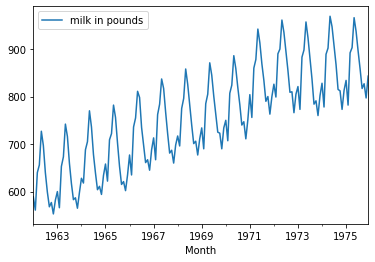

In [ ]:
df.plot()

In [ ]:
#calculate moving avg
# df['12 month MA']=df['milk in pounds'].rolling(12).mean()
# df['12 month STD']=df['milk in pounds'].rolling(12).std()
# df.plot()

In [ ]:
#ETS decompose
from statsmodels.tsa.seasonal import seasonal_decompose


In [ ]:
decomp = seasonal_decompose(df)

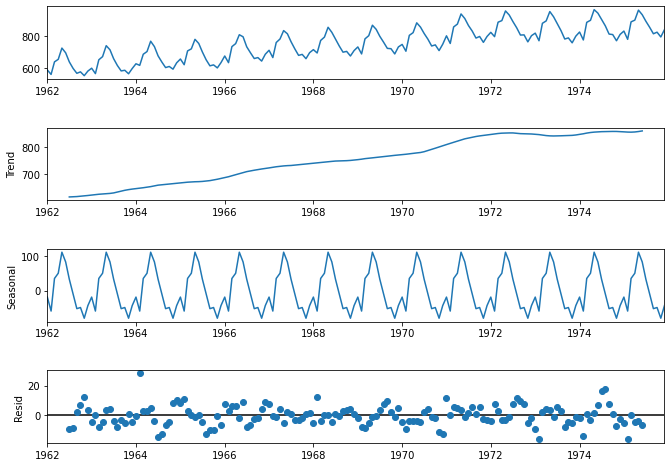

In [ ]:
fig = decomp.plot()
fig.set_size_inches(10,7)

In [ ]:
df.head()

,milk in pounds
Month,
1962-01-01,589.0
1962-02-01,561.0
1962-03-01,640.0
1962-04-01,656.0
1962-05-01,727.0


In [ ]:
#to check whether the data is stationary or not you have to check it with the augmented dickey fuller unit root
# test. it is a statistical test which has a null hypothesis that it is a non stationary time series. alt 
# hypothesis is that the seires has no unit root and is stationary.
#  p-value - small p val less than 0.05 indicates strong evidennce against the null hypothesis. therefore we
# reject the null hypothesis. p val greater than 0.05 indicates weak evidence against null hyp, therefore we
# we fail to reject null hyp.

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result = adfuller(df['milk in pounds'])

In [ ]:
result

(-1.3038115874221246,
 0.627426708603034,
 13,
 154,
 {'1%': -3.473542528196209,
  '5%': -2.880497674144038,
  '10%': -2.576878053634677},
 1115.1730447395112)

In [ ]:
def adf_check(time_series):
    result = adfuller(time_series)
    print('Augmented dickey fuller test')
    labels=['ADF test statistics','P-values','Number of Lags','Number of obs']
    
    for value,label in zip(result,labels):
        print(label+" : "+str(value))
    if result[1] <= 0.05:
        print('Strong evedince against null hypothesis')
        print('Reject the null hypothesis')
        print('Data has no unit root and is stationary')
    else:
        print('Weak evidence against null hypothesis')
        print('Fail to reject null hypothesis')
        print('Data has a unit root and it is Non-Stationary')
        

In [ ]:
adf_check(df['milk in pounds'])

Augmented dickey fuller test
ADF test statistics : -1.3038115874221246
P-values : 0.627426708603034
Number of Lags : 13
Number of obs : 154
Weak evidence against null hypothesis
Fail to reject null hypothesis
Data has a unit root and it is Non-Stationary


In [ ]:
#clearly from the graph we understood that the data is nonstationary.

In [ ]:
#in order to make it stationary we have to do diffrencing.

In [ ]:
df['lag 1 in milk'] = df['milk in pounds'].shift(periods=1)
df['differencing 1 in milk']=df['milk in pounds']-df['lag 1 in milk']

In [ ]:
adf_check(df['differencing 1 in milk'].dropna())

Augmented dickey fuller test
ADF test statistics : -3.0549955586530553
P-values : 0.03006800400178688
Number of Lags : 14
Number of obs : 152
Strong evedince against null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


<AxesSubplot:xlabel='Month'>

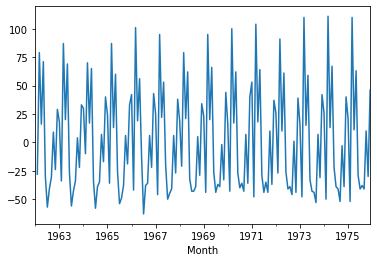

In [ ]:
df['differencing 1 in milk'].plot()

In [ ]:
# but lets say this still wasnt enough to make it stationary
df['difference 2 in milk'] = df['differencing 1 in milk']-df['differencing 1 in milk'].shift(1)

<AxesSubplot:xlabel='Month'>

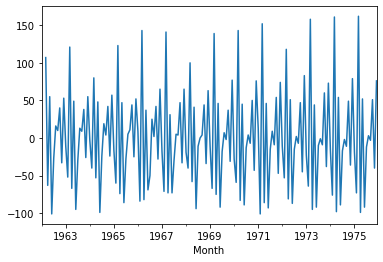

In [ ]:
df['difference 2 in milk'].plot()

In [ ]:
adf_check(df['difference 2 in milk'].dropna())

Augmented dickey fuller test
ADF test statistics : -14.327873645603336
P-values : 1.1126989332083069e-26
Number of Lags : 11
Number of obs : 154
Strong evedince against null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [ ]:
df['seasonal difference for milk'] = df['milk in pounds'] - df['milk in pounds'].shift(12)

<AxesSubplot:xlabel='Month'>

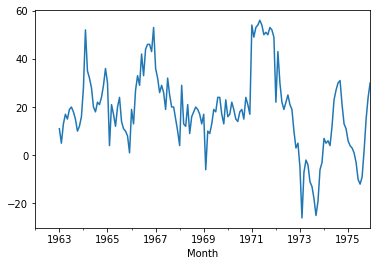

In [ ]:
df['seasonal difference for milk'].plot()

In [ ]:
adf_check(df['seasonal difference for milk'].dropna())

Augmented dickey fuller test
ADF test statistics : -2.3354193143593993
P-values : 0.16079880527711304
Number of Lags : 12
Number of obs : 143
Weak evidence against null hypothesis
Fail to reject null hypothesis
Data has a unit root and it is Non-Stationary


In [ ]:
df['seasonal first difference']= df['differencing 1 in milk']-df['differencing 1 in milk'].shift(12)

<AxesSubplot:xlabel='Month'>

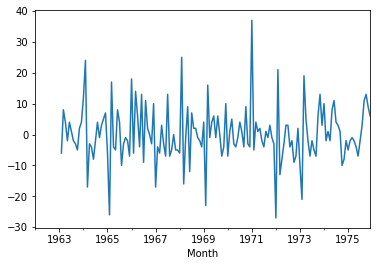

In [ ]:
df['seasonal first difference'].plot()

In [ ]:
adf_check(df['seasonal first difference'].dropna())

Augmented dickey fuller test
ADF test statistics : -5.038002274921985
P-values : 1.86542343187882e-05
Number of Lags : 11
Number of obs : 143
Strong evedince against null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


# ACF and PACF

In [ ]:
df.head()

,milk in pounds,lag 1 in milk,differencing 1 in milk,difference 2 in milk,seasonal difference for milk,seasonal first difference
Month,,,,,,
1962-01-01,589.0,NaN,NaN,NaN,NaN,NaN
1962-02-01,561.0,589.0,-28.0,NaN,NaN,NaN
1962-03-01,640.0,561.0,79.0,107.0,NaN,NaN
1962-04-01,656.0,640.0,16.0,-63.0,NaN,NaN
1962-05-01,727.0,656.0,71.0,55.0,NaN,NaN


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

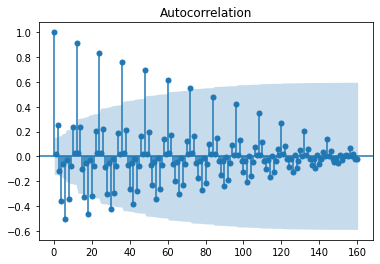

In [ ]:
fig_first= plot_acf(df['differencing 1 in milk'].dropna(),lags=160)

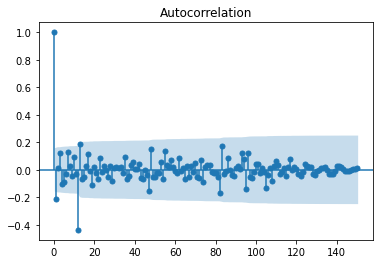

In [ ]:
fig_seasonal_first = plot_acf(df['seasonal first difference'].dropna(),lags=150)

In [ ]:
from pandas.plotting import autocorrelation_plot

<AxesSubplot:xlabel='Lag', ylabel='Autocorrelation'>

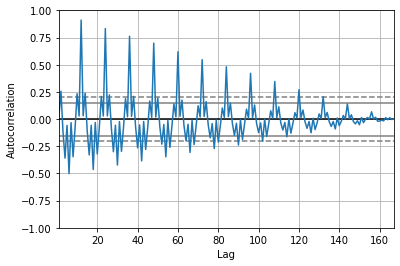

In [ ]:
autocorrelation_plot(df['differencing 1 in milk'].dropna())

<AxesSubplot:xlabel='Lag', ylabel='Autocorrelation'>

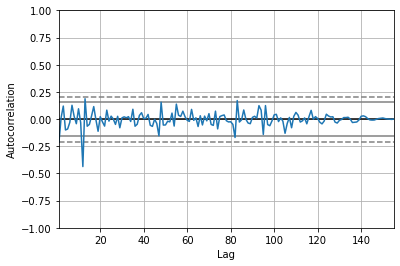

In [ ]:
autocorrelation_plot(df['seasonal first difference'].dropna())

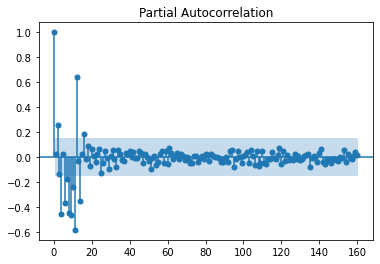

In [ ]:
fig1= plot_pacf(df['differencing 1 in milk'].dropna(),lags=160,method='ywm')

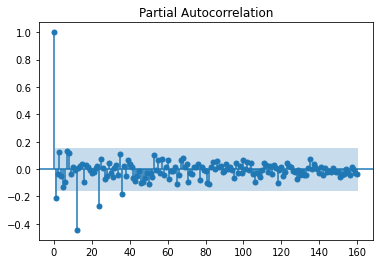

In [ ]:
fig_first= plot_pacf(df['seasonal first difference'].dropna(),method='ywm',lags=160)
#yule - walker model

In [ ]:
# pacf interpretation usually when there is a sudden drop off after lag-K then we use the suto-regresive 
# model of K 

# and of there is a gradual decline then we use the MA model

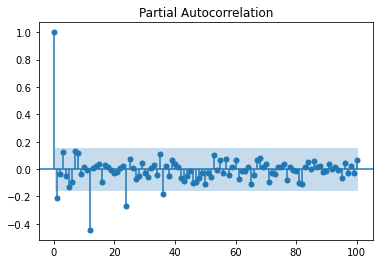

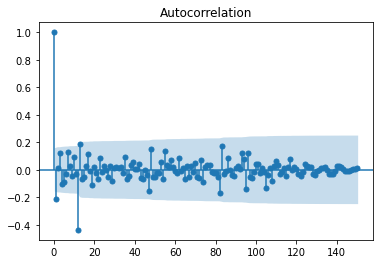

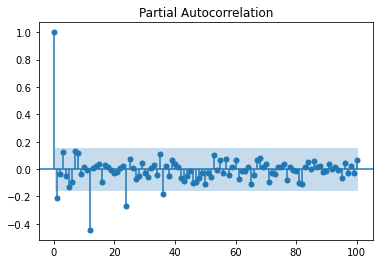

In [ ]:
plot_acf(df['seasonal first difference'].dropna(),lags=150)
plot_pacf(df['seasonal first difference'].dropna(),lags=100,method='ywm')

In [ ]:
from statsmodels.tsa.arima_model import ARIMA

In [ ]:
help(ARIMA)

Help on class ARIMA in module statsmodels.tsa.arima_model:

class ARIMA(ARMA)
 |  ARIMA(endog, order, exog=None, dates=None, freq=None, missing='none')
 |  
 |  Autoregressive Integrated Moving Average ARIMA(p,d,q) Model
 |  
 |  Parameters
 |  ----------
 |  endog : array_like
 |      The endogenous variable.
 |  order : iterable
 |      The (p,d,q) order of the model for the number of AR parameters,
 |      differences, and MA parameters to use.
 |  exog : array_like, optional
 |      An optional array of exogenous variables. This should *not* include a
 |      constant or trend. You can specify this in the `fit` method.
 |  dates : array_like, optional
 |      An array-like object of datetime objects. If a pandas object is given
 |      for endog or exog, it is assumed to have a DateIndex.
 |  freq : str, optional
 |      The frequency of the time-series. A Pandas offset or 'B', 'D', 'W',
 |      'M', 'A', or 'Q'. This is optional if dates are given.
 |  
 |  
 |  Notes
 |  -----
 |

In [ ]:
model = sm.tsa.statespace.SARIMAX(df['milk in pounds'],order=(0,1,0),seasonal_order=(1,1,1,12))

/Users/pradeepjaswani/opt/anaconda3/envs/pyfinance/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
/Users/pradeepjaswani/opt/anaconda3/envs/pyfinance/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'


In [ ]:
result = model.fit()

In [ ]:
print(result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                       milk in pounds   No. Observations:                  168
Model:             SARIMAX(0, 1, 0)x(1, 1, [1], 12)   Log Likelihood                -534.065
Date:                              Tue, 15 Dec 2020   AIC                           1074.131
Time:                                      16:59:39   BIC                           1083.261
Sample:                                  01-01-1962   HQIC                          1077.839
                                       - 12-01-1975                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.0449      0.106     -0.422      0.673      -0.253       0.163
ma.S.L12      -0.58

In [ ]:
result.resid

Month
1962-01-01    589.000000
1962-02-01    -28.000000
1962-03-01     79.000000
1962-04-01     16.000000
1962-05-01     71.000000
                 ...    
1975-08-01      2.641383
1975-09-01      8.158731
1975-10-01      7.676817
1975-11-01      6.572500
1975-12-01      5.936354
Length: 168, dtype: float64

<AxesSubplot:xlabel='Month'>

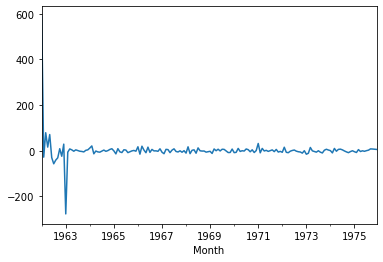

In [ ]:
result.resid.plot()

<AxesSubplot:ylabel='Density'>

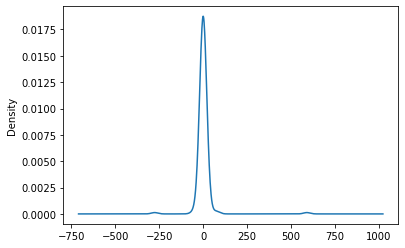

In [ ]:
result.resid.plot(kind="kde")

In [ ]:
# all close to 0. which is good

<AxesSubplot:xlabel='Month'>

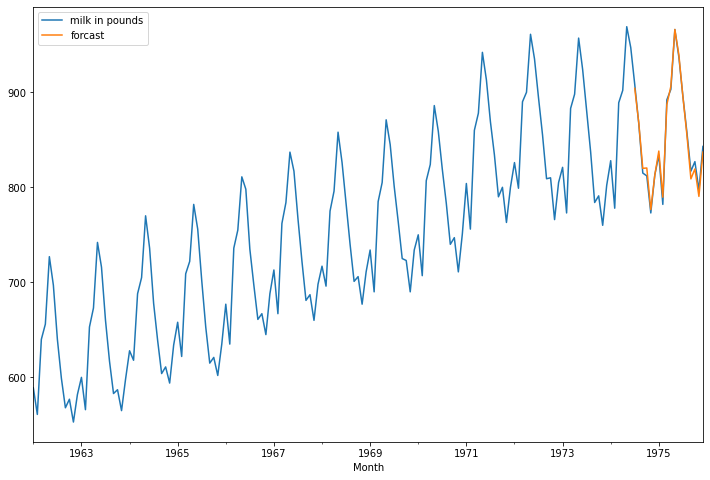

In [ ]:
df['forcast']=result.predict(start=150,end=250)
df[['milk in pounds','forcast']].plot(figsize=(12,8))

In [ ]:
# we see that the prediction is till max 168 days this is a problem as we dont have extra time frames in our
# dataframe we can create more time periods in pandas

In [ ]:
df.tail()

,milk in pounds,lag 1 in milk,differencing 1 in milk,difference 2 in milk,seasonal difference for milk,seasonal first difference,forcast
Month,,,,,,,
1975-08-01,858.0,896.0,-38.0,3.0,-9.0,3.0,855.358617
1975-09-01,817.0,858.0,-41.0,-3.0,2.0,11.0,808.841269
1975-10-01,827.0,817.0,10.0,51.0,15.0,13.0,819.323183
1975-11-01,797.0,827.0,-30.0,-40.0,24.0,9.0,790.427500
1975-12-01,843.0,797.0,46.0,76.0,30.0,6.0,837.063646


In [ ]:
# we add on more time frames with empty values. even tho values are empty we can srill forcast on them.


In [ ]:
from pandas.tseries.offsets import DateOffset

In [ ]:
fd = [df.index[-1] + DateOffset(months=x) for x in range(1,48)]

In [ ]:
fd

[Timestamp('1976-01-01 00:00:00'),
 Timestamp('1976-02-01 00:00:00'),
 Timestamp('1976-03-01 00:00:00'),
 Timestamp('1976-04-01 00:00:00'),
 Timestamp('1976-05-01 00:00:00'),
 Timestamp('1976-06-01 00:00:00'),
 Timestamp('1976-07-01 00:00:00'),
 Timestamp('1976-08-01 00:00:00'),
 Timestamp('1976-09-01 00:00:00'),
 Timestamp('1976-10-01 00:00:00'),
 Timestamp('1976-11-01 00:00:00'),
 Timestamp('1976-12-01 00:00:00'),
 Timestamp('1977-01-01 00:00:00'),
 Timestamp('1977-02-01 00:00:00'),
 Timestamp('1977-03-01 00:00:00'),
 Timestamp('1977-04-01 00:00:00'),
 Timestamp('1977-05-01 00:00:00'),
 Timestamp('1977-06-01 00:00:00'),
 Timestamp('1977-07-01 00:00:00'),
 Timestamp('1977-08-01 00:00:00'),
 Timestamp('1977-09-01 00:00:00'),
 Timestamp('1977-10-01 00:00:00'),
 Timestamp('1977-11-01 00:00:00'),
 Timestamp('1977-12-01 00:00:00'),
 Timestamp('1978-01-01 00:00:00'),
 Timestamp('1978-02-01 00:00:00'),
 Timestamp('1978-03-01 00:00:00'),
 Timestamp('1978-04-01 00:00:00'),
 Timestamp('1978-05-

In [ ]:
#concat fd 

In [ ]:
fdf= pd.DataFrame(index=fd,columns=df.columns)

In [ ]:
fdf

,milk in pounds,lag 1 in milk,differencing 1 in milk,difference 2 in milk,seasonal difference for milk,seasonal first difference,forcast
1976-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
finaldf = pd.concat([df,fdf])

In [ ]:
finaldf.tail()

,milk in pounds,lag 1 in milk,differencing 1 in milk,difference 2 in milk,seasonal difference for milk,seasonal first difference,forcast
1979-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<AxesSubplot:>

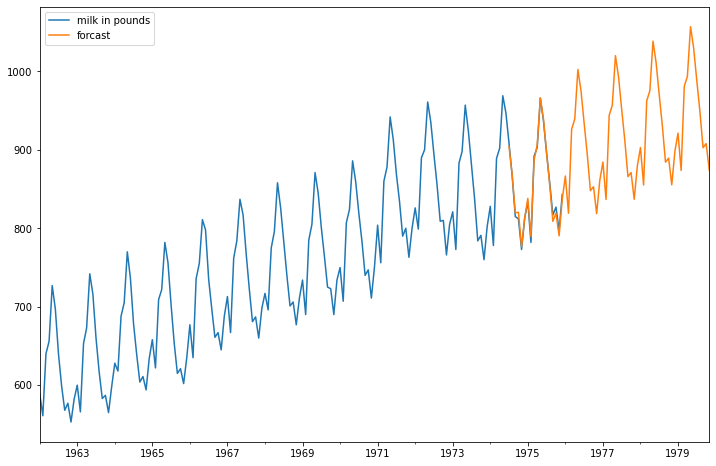

In [ ]:
#now that we have empty rows we can forcast.
finaldf['forcast']=result.predict(start=150,end=216)
finaldf[['milk in pounds','forcast']].plot(figsize=(12,8))